# BERT-Based Text Classification — BioBERT / Bio_ClinicalBERT / ClinicalBERT / SciBERT
## Version history
- 2026-01-26 v001 — Initial BERT strategy, separated from baseline models  
- 2026-01-28 v003 — Re-setup Transformer-based classification  
- 2026-01-26 v007 — Bug fixes & refactor (eval_strategy, bf16, naming, structure)

## Overview
Four pre-trained BERT variants are compared for binary text classification on medical/clinical data.

| Model | Hugging Face ID | Notes |
|---|---|---|
| BioBERT | `dmis-lab/biobert-base-cased-v1.1` | PubMed / PMC pre-training |
| Bio_ClinicalBERT | `emilyalsentzer/Bio_ClinicalBERT` | BioBERT + MIMIC-III clinical notes |
| ClinicalBERT | `medicalai/ClinicalBERT` | Multicenter EHR pre-training |
| SciBERT | `allenai/scibert_scivocab_uncased` | General scientific text |

- 2026-03-30 v010 — Evaluation section: unified CI summary table + CI bar chart - debugging...


## 1. Installation

In [1]:
# ── Install PyTorch (ROCm 5.7 for AMD GPUs; replace the URL for CUDA or CPU builds)
# %pip install --upgrade pip
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/rocm5.7

# ── Core libraries (run once; restart kernel afterwards)
# %pip install pandas numpy matplotlib seaborn scikit-learn
# %pip install "transformers[torch]>=4.38" "accelerate>=0.26.0"


## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc as auc_score,
    precision_recall_curve,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)


/home/schrader/GithubDir/PEDro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration
All tunable parameters are collected here so nothing is scattered across cells.

In [3]:
# ── Data
DATA_FILE      = "PedroData_CleanedText_Final.csv"
TEXT_COL       = "textcomplete"   # combined Title + Abstract column
LABEL_COL      = "Label"

# ── Model
MODEL_NAME     = "emilyalsentzer/Bio_ClinicalBERT"
NUM_LABELS     = 2
MAX_LENGTH     = 128              # token truncation length

# ── Training hyper-parameters
BATCH_SIZE     = 8
NUM_EPOCHS     = 3
LEARNING_RATE  = 2e-5
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.1
SEED           = 42

# ── Paths
OUTPUT_DIR     = "./results"
LOGGING_DIR    = "./logs"

# ── Bootstrap CI
N_BOOTSTRAP    = 100


## 4. Device Setup

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")

if torch.cuda.is_available():
    print(f"CUDA    : {torch.version.cuda}")
    print(f"GPU     : {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.device_count()} device(s))")
    torch.backends.cudnn.benchmark = True

# BUG-FIX: bf16 requires Ampere (sm_80) or newer — is_available() is not enough.
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"bf16    : {USE_BF16}")


PyTorch : 2.10.0+cu128
Device  : cpu
bf16    : False


## 5. Load & Prepare Data

In [5]:
# Load raw CSV
data = pd.read_csv(DATA_FILE)
print("Columns:", data.columns.tolist())
print("Shape  :", data.shape)

# ── Combine Title + Abstract into a single text field
# FIX: work on a copy from the start so `data` is never mutated
df = data.copy()
df[TEXT_COL] = df["Title"].fillna("") + " " + df["Abstract"].fillna("")

# ── Label distribution
print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())   # BUG-FIX: was discarded silently


Columns: ['Title', 'Abstract', 'Label', 'Title_WordCount', 'Abstract_WordCount']
Shape  : (13373, 5)

Label distribution:
Label
0    10673
1     2700
Name: count, dtype: int64


## 6. Train / Test Split

In [6]:
X = df[TEXT_COL].tolist()
y = df[LABEL_COL].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"Train label distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test  label distribution: {pd.Series(y_test).value_counts().to_dict()}")


Train size : 10698
Test size  : 2675
Train label distribution: {0: 8538, 1: 2160}
Test  label distribution: {0: 2135, 1: 540}


## 7. Tokenisation

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=MAX_LENGTH)
test_encodings  = tokenizer(X_test,  truncation=True, padding=True, max_length=MAX_LENGTH)

print(f"Tokenised with '{MODEL_NAME}', max_length={MAX_LENGTH}")


Tokenised with 'emilyalsentzer/Bio_ClinicalBERT', max_length=128


## 8. PyTorch Dataset

In [8]:
class MedicalDataset(Dataset):
    """Wraps HuggingFace BatchEncoding + label list as a torch Dataset."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Convert each tokeniser field to a tensor and add the label
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = MedicalDataset(train_encodings, y_train)
test_dataset  = MedicalDataset(test_encodings,  y_test)
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")


Train samples: 10698 | Test samples: 2675


## 9. Load Model

In [9]:
# BUG-FIX: comment previously said "Load BioBERT" but the model is Bio_ClinicalBERT
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={0: "Class 0", 1: "Class 1"},
    label2id={"Class 0": 0, "Class 1": 1},
).to(device)

print(f"Loaded: {MODEL_NAME}  →  {NUM_LABELS}-class head  on {device}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 75324.11it/s]
BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those para

Loaded: emilyalsentzer/Bio_ClinicalBERT  →  2-class head  on cpu


## 10. Metric Helpers
Defined as standalone functions so they can be reused across models.

In [10]:
def compute_metrics(pred):
    """Called by HuggingFace Trainer after each evaluation step."""
    labels     = pred.label_ids
    preds      = pred.predictions.argmax(-1)
    pred_probs = (
        F.softmax(torch.from_numpy(pred.predictions).float(), dim=1)
        .cpu().numpy()
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    # BUG-FIX: renamed local variable from `auc` → `roc_auc_val`
    #          to avoid shadowing the imported `auc_score` function.
    # BUG-FIX: bare `except` replaced with `except ValueError`
    try:
        roc_auc_val = roc_auc_score(labels, pred_probs[:, 1])
    except ValueError:
        roc_auc_val = float("nan")

    return {
        "accuracy" : acc,
        "f1"       : f1,
        "precision": precision,
        "recall"   : recall,
        "auc"      : roc_auc_val,
    }


def bootstrap_metrics(y_true, y_pred, y_prob, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    """Return mean + 95 % bootstrap CIs for Accuracy, Precision, Recall, F1, AUC."""
    rng  = np.random.RandomState(seed)
    n    = len(y_true)
    cols = ["accuracy", "precision", "recall", "f1", "auc"]
    samples = {m: [] for m in cols}

    for _ in range(n_bootstrap):
        idx        = rng.randint(0, n, n)
        yt, yp, yb = np.array(y_true)[idx], np.array(y_pred)[idx], np.array(y_prob)[idx]

        samples["accuracy"].append(accuracy_score(yt, yp))
        samples["precision"].append(precision_score(yt, yp, zero_division=0))
        samples["recall"].append(recall_score(yt, yp, zero_division=0))
        samples["f1"].append(f1_score(yt, yp, zero_division=0))
        try:
            samples["auc"].append(roc_auc_score(yt, yb))
        except ValueError:
            samples["auc"].append(np.nan)

    ci = {}
    for metric, vals in samples.items():
        arr = np.array(vals)
        ci[metric] = (np.nanmean(arr), np.nanpercentile(arr, 2.5), np.nanpercentile(arr, 97.5))
    return ci


## 11. Training

In [11]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # ── Core hyper-parameters
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    adam_epsilon=1e-8,

    # ── BUG-FIX: eval_strategy was MISSING — Trainer never evaluated during training
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    # ── Checkpointing & logging
    save_total_limit=2,
    logging_dir=LOGGING_DIR,
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    report_to="none",

    # ── Hardware
    # BUG-FIX: bf16 requires Ampere GPU — is_available() alone is not sufficient
    bf16=USE_BF16,
    dataloader_num_workers=4,
    dataloader_pin_memory=torch.cuda.is_available(),

    # ── Reproducibility
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training …")
trainer.train()


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training …


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.209562,0.246250,0.916636,0.795600,0.787659,0.803704,0.958613
2,0.221578,0.273632,0.922617,0.815013,0.787565,0.844444,0.963967
3,0.083886,0.340395,0.925607,0.822796,0.792453,0.855556,0.964432


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.61it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=4014, training_loss=0.20545263465551458, metrics={'train_runtime': 3254.4226, 'train_samples_per_second': 9.862, 'train_steps_per_second': 1.233, 'total_flos': 2111071552680960.0, 'train_loss': 0.20545263465551458, 'epoch': 3.0})

## 12. Evaluation
Point estimates from `trainer.evaluate()` and 95% bootstrap confidence intervals
are computed together and displayed as a unified summary table, then visualised
as a bar chart with error bands.


In [12]:
# ════════════════════════════════════════════════════════════════════
# Fix — remove NotebookProgressCallback (requires on_train_begin,
#        which is never called when evaluating a loaded model directly)
# ════════════════════════════════════════════════════════════════════
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# ════════════════════════════════════════════════════════════════════
# Step 1 — Trainer-level point estimates  (uses compute_metrics)
# ════════════════════════════════════════════════════════════════════
print("Evaluating …")
results = trainer.evaluate()

# Point estimates keyed by metric name (strip the "eval_" prefix for convenience)
point_estimates = {
    "accuracy" : results["eval_accuracy"],
    "precision": results["eval_precision"],
    "recall"   : results["eval_recall"],
    "f1"       : results["eval_f1"],
    "auc"      : results["eval_auc"],
}

# ════════════════════════════════════════════════════════════════════
# Step 2 — Full predictions + positive-class probability scores
# ════════════════════════════════════════════════════════════════════
predictions = trainer.predict(test_dataset)
preds       = np.argmax(predictions.predictions, axis=-1)

y_scores = (
    F.softmax(torch.from_numpy(predictions.predictions).float(), dim=1)
    .cpu().numpy()[:, 1]
)

# ════════════════════════════════════════════════════════════════════
# Step 3 — 95 % bootstrap confidence intervals
# ════════════════════════════════════════════════════════════════════
# bootstrap_metrics() resamples the test set N_BOOTSTRAP times (with replacement)
# and returns (mean, 2.5th-percentile, 97.5th-percentile) for each metric.
ci = bootstrap_metrics(y_test, preds, y_scores, n_bootstrap=N_BOOTSTRAP, seed=SEED)

# ════════════════════════════════════════════════════════════════════
# Step 4 — Unified summary table: point estimate + CI side by side
# ════════════════════════════════════════════════════════════════════
METRICS = ["accuracy", "precision", "recall", "f1", "auc"]

rows = []
for m in METRICS:
    bs_mean, lo, hi = ci[m]
    rows.append({
        "Metric"            : m.capitalize(),
        "Point Estimate"    : point_estimates[m],
        "Bootstrap Mean"    : bs_mean,
        "CI Low  (2.5 %)"   : lo,
        "CI High (97.5 %)"  : hi,
        "95 % CI"           : f"[{lo:.4f}, {hi:.4f}]",
    })

df_eval = pd.DataFrame(rows).set_index("Metric")

print(f"\n{'─'*62}")
print(f"  Evaluation Summary   (bootstrap n = {N_BOOTSTRAP}, seed = {SEED})")
print(f"{'─'*62}")
print(
    df_eval[["Point Estimate", "Bootstrap Mean",
             "CI Low  (2.5 %)", "CI High (97.5 %)", "95 % CI"]]
    .to_string(float_format="{:.4f}".format)
)
print(f"{'─'*62}")

# ════════════════════════════════════════════════════════════════════
# Step 5 — Classification report, confusion matrix, cross-table
# ════════════════════════════════════════════════════════════════════
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=["Class 0", "Class 1"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nCross Table (Actual vs Predicted):")
ct = pd.crosstab(
    pd.Series(y_test, name="Actual"),
    pd.Series(preds,  name="Predicted"),
    margins=True,
)
print(ct)


Evaluating …

──────────────────────────────────────────────────────────────
  Evaluation Summary   (bootstrap n = 100, seed = 42)
──────────────────────────────────────────────────────────────
           Point Estimate  Bootstrap Mean  CI Low  (2.5 %)  CI High (97.5 %)           95 % CI
Metric                                                                                        
Accuracy           0.9256          0.9255           0.9164            0.9339  [0.9164, 0.9339]
Precision          0.7925          0.7914           0.7694            0.8138  [0.7694, 0.8138]
Recall             0.8556          0.8556           0.8206            0.8803  [0.8206, 0.8803]
F1                 0.8228          0.8222           0.7978            0.8429  [0.7978, 0.8429]
Auc                0.9644          0.9638           0.9562            0.9714  [0.9562, 0.9714]
──────────────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support


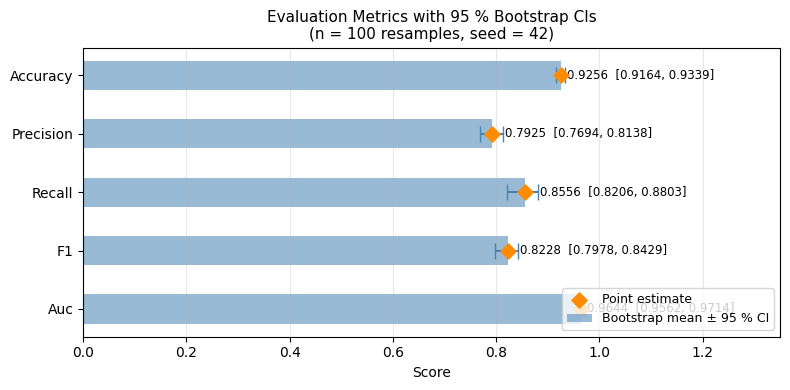

In [13]:
# ════════════════════════════════════════════════════════════════════
# Visualise bootstrap 95 % CIs as a horizontal bar chart
# ════════════════════════════════════════════════════════════════════
metric_labels = df_eval.index.tolist()
point_vals    = df_eval["Point Estimate"].values
bs_means      = df_eval["Bootstrap Mean"].values
ci_low        = df_eval["CI Low  (2.5 %)"].values
ci_high       = df_eval["CI High (97.5 %)"].values

# Asymmetric error bar widths relative to the bootstrap mean
err_low  = bs_means - ci_low
err_high = ci_high  - bs_means

fig, ax = plt.subplots(figsize=(8, 4))

y_pos = np.arange(len(metric_labels))

# ── Bootstrap CI bars (grey, wide)
ax.barh(
    y_pos, bs_means,
    xerr=[err_low, err_high],
    height=0.5,
    color="steelblue", alpha=0.55,
    capsize=6, ecolor="steelblue",
    label="Bootstrap mean ± 95 % CI",
)

# ── Point estimate markers (solid diamonds on top)
ax.scatter(
    point_vals, y_pos,
    color="darkorange", zorder=5, s=60, marker="D",
    label="Point estimate",
)

# ── Annotation: value labels on the right side of each bar
for i, (pt, lo, hi) in enumerate(zip(point_vals, ci_low, ci_high)):
    ax.text(
        hi + 0.004, i,
        f"{pt:.4f}  [{lo:.4f}, {hi:.4f}]",
        va="center", fontsize=8.5, color="black",
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(metric_labels, fontsize=10)
ax.set_xlim(0, 1.35)          # leave room for annotations
ax.set_xlabel("Score")
ax.set_title(
    f"Evaluation Metrics with 95 % Bootstrap CIs\n"
    f"(n = {N_BOOTSTRAP} resamples, seed = {SEED})",
    fontsize=11,
)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()              # top-to-bottom order matches the table

plt.tight_layout()
plt.savefig("evaluation_ci.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Visualisation

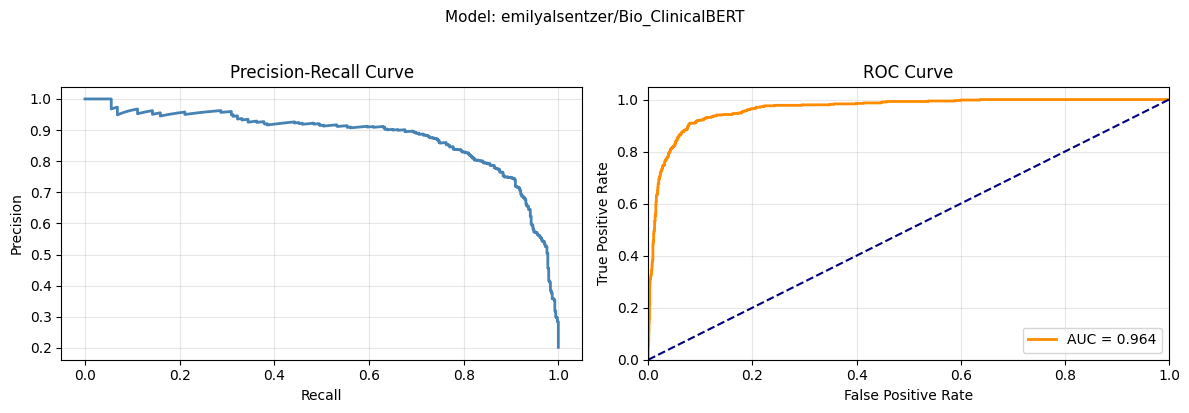

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_scores)
axes[0].plot(recall_vals, precision_vals, color="steelblue", lw=2)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve")
axes[0].grid(alpha=0.3)

# ── ROC curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc_score(fpr, tpr)         # uses the imported auc_score, no naming conflict
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.suptitle(f"Model: {MODEL_NAME}", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("evaluation_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Save Model (optional)

In [15]:
trainer.save_model("bio_clinicalbert_classifier")
tokenizer.save_pretrained("bio_clinicalbert_classifier")
print("Model saved.")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.58it/s]

Model saved.
